In [4]:
# Importing necessary libraries
import pandas as pd
import shap
import joblib
import catboost
import matplotlib.pyplot as plt
%matplotlib inline
shap.initjs()

In [5]:
# Step 2: Load the saved CatBoost model and test data

# Load the CatBoost model (make sure the .cbm file is in your working directory)
from catboost import CatBoostClassifier

# Load the test data with predicted PD column
df_test = pd.read_csv('predictions_with_PD.csv')

# Show the first few rows to confirm
df_test.head()


,0,1,2,3,4,5,6,7,8,9,PD
0,0.191895,0.134756,-0.013454,0.191895,0.134756,-0.002582,-0.001813,0.036824,0.025859,0.018159,0.460964
1,0.594241,0.884431,-0.964599,0.594241,0.884431,-0.573204,-0.853121,0.353122,0.525565,0.782219,0.344849
2,1.030116,0.884431,0.797112,1.030116,0.884431,0.821118,0.704991,1.061139,0.911067,0.782219,0.332164
3,0.080132,0.134756,-0.970581,0.080132,0.134756,-0.077775,-0.130792,0.006421,0.010798,0.018159,0.458855
4,-0.116570,-0.614919,0.399307,-0.116570,-0.614919,-0.046547,-0.245541,0.013589,0.071681,0.378125,0.615052


No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


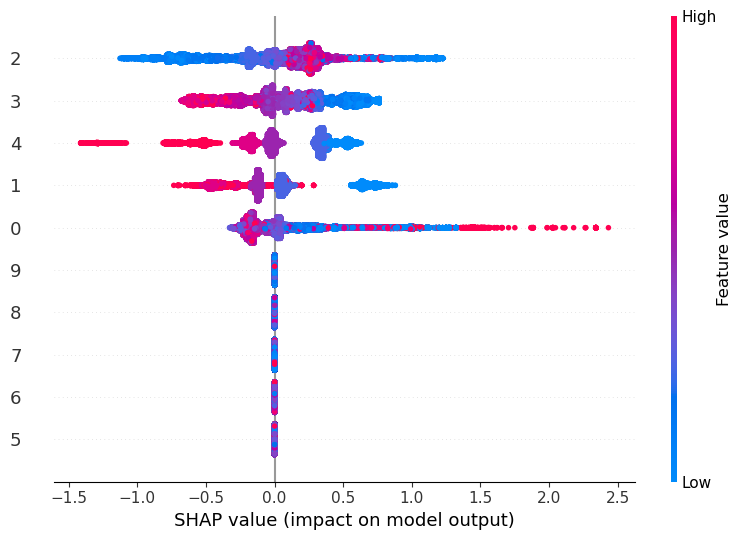

In [6]:
from catboost import CatBoostClassifier
import shap
import pandas as pd

# Load model and test data
model = CatBoostClassifier()
model.load_model("catboost_model.cbm")

df_test = pd.read_csv("predictions_with_PD.csv")

# Prepare SHAP
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(df_test.drop(columns=["PD"]))

# SHAP Summary Plot
shap.summary_plot(shap_values, df_test.drop(columns=["PD"]))


In [8]:
# Get feature names used in the model
df_test.columns


Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'PD'], dtype='object')

In [10]:
df_test.shape


(79206, 11)

In [ ]:
# Updated feature columns (ensure the list matches the 10 features in df_test)
feature_columns = ['loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 
                   'emp_title', 'emp_length', 'home_ownership', 'annual_inc']

# Assign the feature names to df_test columns (including 'PD')
df_test.columns = feature_columns + ['PD']

# Verify the updated column names
df_test.head()


In [13]:
# Assign proper column names
df_test.columns = [
    'loan_amnt',                  # float64
    'int_rate',                   # float64
    'installment',                # float64
    'annual_inc',                 # float64
    'dti',                        # float64
    'revol_util',                 # float64
    'total_acc',                  # float64
    'mort_acc',                   # float64
    'pub_rec_bankruptcies',       # float64
    'home_ownership_RENT',        # 1 or 0 → one-hot encoded
    'PD'                          # predicted probability (target/output), This is the prediction, not a feature
]


# Prepare test data for SHAP (exclude 'PD' column)
X_test_shap = df_test.drop(columns=['PD'])


No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


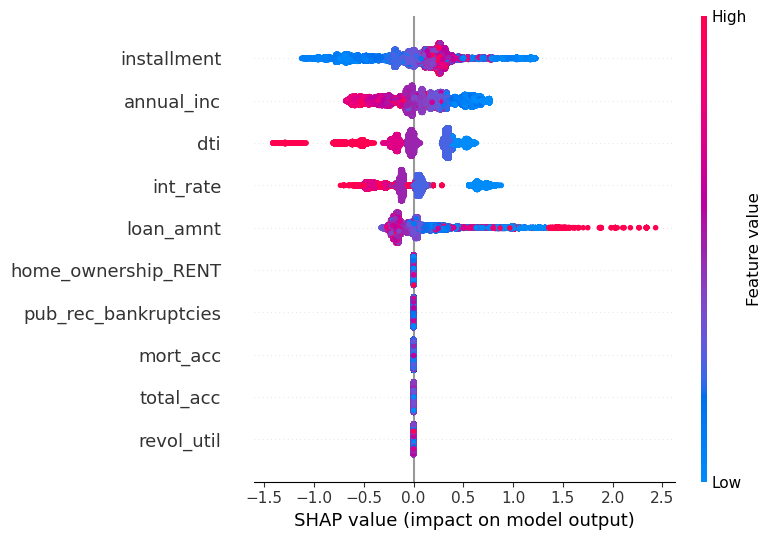

In [14]:
from catboost import CatBoostClassifier
import shap
import pandas as pd

# Load model and test data
model = CatBoostClassifier()
model.load_model("catboost_model.cbm")

df_test = pd.read_csv("predictions_with_PD.csv")

# Prepare SHAP/ # Initialise SHAP explainer
explainer = shap.TreeExplainer(model)

# Get SHAP values
shap_values = explainer.shap_values(X_test_shap)

# Generate SHAP summary plot
shap.summary_plot(shap_values, X_test_shap)